# 0. Imports

In [7]:
!pip install umap-learn shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.1 MB 7.4 MB/s eta 0:00:05
   -- ------------------------------------- 2.6/38.1 MB 6.8 MB/s eta 0:00:06
   ---- ----------------------------------- 4.5/38.1 MB 7.3 MB/s eta 0:00:05
   ------ --------------------------------- 5.8/38.1 MB 7.2 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/38.1 MB 7.5 MB/s eta 0:00:05
   --------- ------------------------------ 9.4/38.1 MB 7.7 MB/s eta 0:00:04
   ---------- ------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Sistema
import os
import zipfile

# Principais imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import datetime
# from google.colab import drive
# drive.mount('/content/drive')

# Classificadores
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier # Arvore de Decisao
from sklearn.ensemble import RandomForestClassifier # Floresta de Decisao
from sklearn.svm import SVC # Support Vector Machine
from xgboost import XGBClassifier # XGBoost
from lightgbm import LGBMClassifier # LGBM
from sklearn.svm import LinearSVC # Linear Support Vector Machine
from sklearn.dummy import DummyClassifier # Classificador aleatorio
from catboost import CatBoostClassifier # CatBoost
from sklearn.linear_model import LogisticRegression # Regressao Logistica

# Clustering
from sklearn.cluster import KMeans

# Avaliadores
from sklearn.metrics import classification_report # Acc, Precision, Recall e F1-Score
from sklearn.metrics import ConfusionMatrixDisplay # Matriz de confusao
from sklearn.metrics import roc_auc_score # area sob curva roc
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, accuracy_score # Metricas
from sklearn.model_selection import cross_val_score # CrossValidation com uma metrica
from sklearn.model_selection import cross_validate # CrossValidation com mais de uma metrica

# Pre processamento
from sklearn.preprocessing import StandardScaler # Normaliza feature media = 0 e desvpad = 1
from sklearn.preprocessing import OneHotEncoder # Encoda uma coluna categorica
from sklearn.impute import SimpleImputer # Imputer: Preenche uma determinada feature
from imblearn.over_sampling import SMOTE # SMOTE

# Datasets nativos SKLearn
from sklearn.datasets import load_digits # Digitos Manuscritos

# DeepLearning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Utilidades
from sklearn.pipeline import make_pipeline # Cria pipeline
from sklearn.pipeline import Pipeline # Executa um pipeline
from sklearn.compose import ColumnTransformer # Aplica transformacoes em colunas
from sklearn.model_selection import train_test_split # Separa treino e teste
from sklearn.model_selection import StratifiedKFold # Estratifica os dados igualmente
from sklearn.model_selection import GridSearchCV # Busca exaustiva
from sklearn.model_selection import RandomizedSearchCV # Busca exaustiva aleatória
from sklearn.manifold import TSNE # TSNE visualização de clusters
import umap # umap visualização de clusters
import shap
from sklearn.decomposition import PCA # Redução de dimensionalidade
from sklearn.metrics import silhouette_score, davies_bouldin_score

c:\Users\Caio\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load Data

In [50]:
# Load  MNIST
mnist = keras.datasets.mnist

cifar = keras.datasets.cifar100

# 2. Data Exploration

## 2.1. MNIST

In [57]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

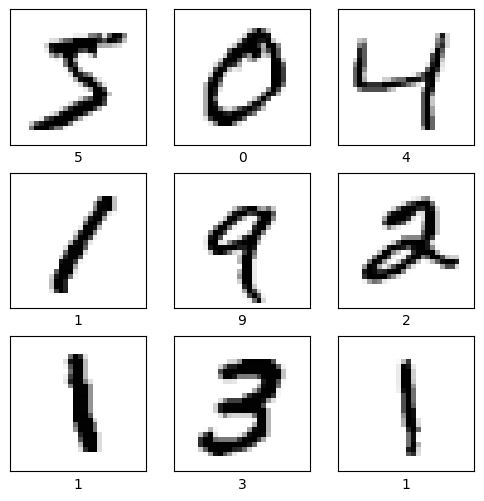

In [16]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

In [18]:
print(f'Shape matriz de treino: {train_images.shape}')
print(f'Shape matriz de teste: {test_images.shape}')

Shape matriz de treino: (60000, 28, 28)
Shape matriz de teste: (10000, 28, 28)


In [29]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [34]:
# Normalizando as matrizes

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

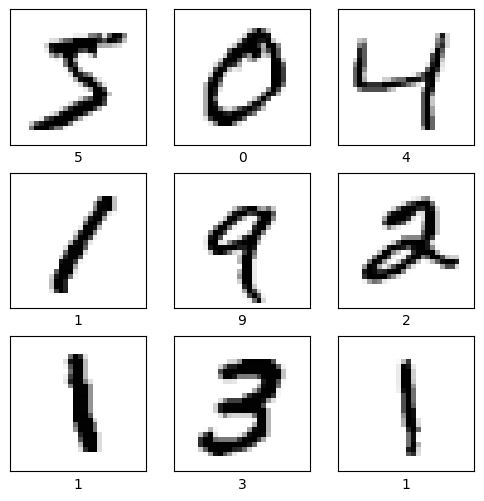

In [35]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

## 2.2. CIFAR100

In [51]:
(train_images, train_labels), (test_images, test_labels) = cifar.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


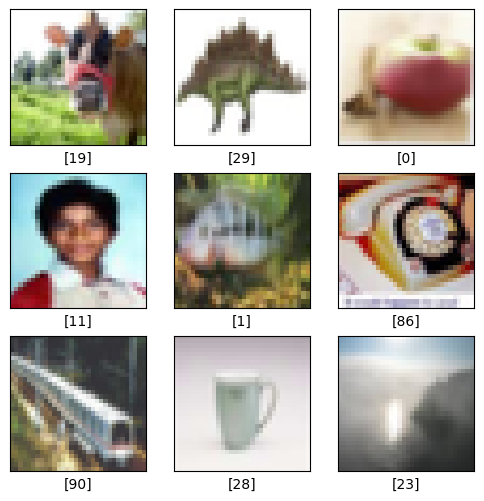

In [52]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

In [ ]:
# Diferente do MNIST, agora temos imagens coloridas em 32x32 e com 3 canais (RGB!)
print(f'Shape matriz de treino: {train_images.shape}')
print(f'Shape matriz de teste: {test_images.shape}')

Shape matriz de treino: (50000, 32, 32, 3)
Shape matriz de teste: (10000, 32, 32, 3)


In [54]:
train_images[0]

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [195, 205, 193],
        [212, 224, 204],
        [182, 194, 167]],

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [170, 176, 150],
        [161, 168, 130],
        [146, 154, 113]],

       [[255, 255, 255],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [189, 199, 169],
        [166, 178, 130],
        [121, 133,  87]],

       ...,

       [[148, 185,  79],
        [142, 182,  57],
        [140, 179,  60],
        ...,
        [ 30,  17,   1],
        [ 65,  62,  15],
        [ 76,  77,  20]],

       [[122, 157,  66],
        [120, 155,  58],
        [126, 160,  71],
        ...,
        [ 22,  16,   3],
        [ 97, 112,  56],
        [141, 161,  87]],

       [[ 87, 122,  41],
        [ 88, 122,  39],
        [101, 134,  56],
        ...,
        [ 34,  36,  10],
        [105, 133,  59],
        [138, 173,  79]]

In [55]:
# Normalizando as matrizes

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

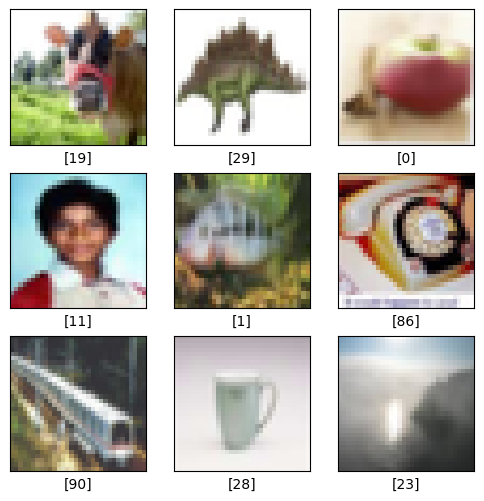

In [56]:
plt.figure(figsize = (6, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i], cmap = 'binary')
    plt.xlabel(train_labels[i])

# 3. Modelos de Redes Neurais

## 3.1. MLP (Multi Layer Perceptron)

### 3.1.1. MLP MNIST

In [ ]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

In [45]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (28, 28)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(128, activation = tf.nn.relu), # Camada oculta: 128 neurônios e função de ativação relu
    keras.layers.Dense(10, activation = tf.nn.softmax) # Camada de Output: 10 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

In [46]:
model_mlp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model_mlp.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9259 - loss: 0.2581
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9660 - loss: 0.1169
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0849
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9801 - loss: 0.0676
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9833 - loss: 0.0572
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9863 - loss: 0.0479
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9880 - loss: 0.0411
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9898 - loss: 0.0365
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9914 - loss: 0.0308
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9923 - loss: 0.0263


In [48]:
test_loss, test_acc = model_mlp.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.9787 - loss: 0.0906
 Loss no teste: 0.09063752740621567 
 Accuracy no teste: 0.9786999821662903


### 3.1.2. MLP CIFAR100

In [59]:
(train_images, train_labels), (test_images, test_labels) = cifar.load_data()

train_images = train_images/np.max(train_images)
test_images = test_images/np.max(test_images)

In [ ]:
#   O MLP é um modelo totalmente conectado, isso significa que todos os neurônios de entrada são utilizados como
# input para os neurônios nas camadas ocultas
#   No modelos mais simples possível (camada de input, oculta e output), o modelo receberá como input 28*28 = 784

model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape = (32, 32, 3)), # Camada de input: Flatten - transforma a matriz 28*28 em um vetor de 784 dimensoes
    keras.layers.Dense(256, activation = tf.nn.relu), # Camada oculta: 256 neurônios e função de ativação relu
    keras.layers.Dense(100, activation = tf.nn.softmax) # Camada de Output: 100 neurônios e função de ativação softmax
])

model_mlp.compile(loss = 'sparse_categorical_crossentropy', # sparse_categorical pois a saida (train_label) é sparsa (UMA coluna de 0 a 9)
                  metrics = ['accuracy'])

In [67]:
model_mlp.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,388 (3.10 MB)

 Trainable params: 812,388 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
history = model_mlp.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1317 - loss: 3.8042
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1296 - loss: 3.8152
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1320 - loss: 3.8155
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1314 - loss: 3.8187
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1315 - loss: 3.8249
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1303 - loss: 3.8365
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1303 - loss: 3.8367
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1278 - loss: 3.8518
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1309 - loss: 3.8498
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1277 - loss: 3.8621


In [70]:
test_loss, test_acc = model_mlp.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0981 - loss: 4.0964
 Loss no teste: 4.09643030166626 
 Accuracy no teste: 0.09809999912977219


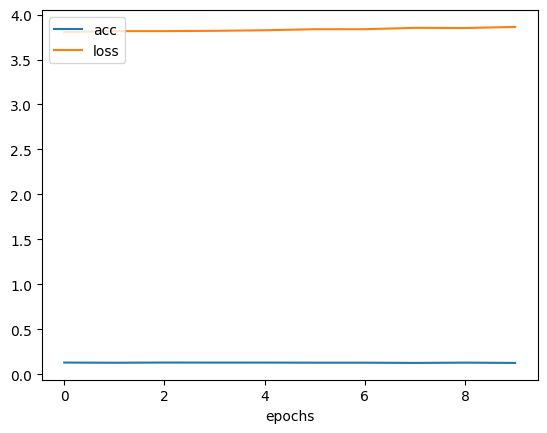

In [72]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.legend(['acc', 'loss'], loc = 'upper left')
plt.show()

## 3.2. CNN (Convolutional Neural Network)

In [80]:
model_cnn = keras.Sequential()

# Convolução 1: Recebe 32x32x3 e retorna 32x32x32 (z = 32 devido a quantidade de filtros)
model_cnn.add(keras.layers.Conv2D(filters = 32, # 32 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same', 
                                  activation = 'relu', # Função de ativação
                                  input_shape = (32, 32, 3) # Dimensões do input
                                  ))
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))

# Convolução 2
model_cnn.add(keras.layers.Conv2D(filters = 64, # 64 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same', 
                                  activation = 'relu' 
                                  ))
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))

# Convolução 2
model_cnn.add(keras.layers.Conv2D(filters = 128, # 64 filtros/kernels
                                  kernel_size = 5, # Dimensões do filtro/kernel
                                  padding = 'same', 
                                  activation = 'relu' 
                                  ))
model_cnn.add(keras.layers.MaxPooling2D(pool_size = [2, 2],
                                        strides = 2))

model_cnn.add(keras.layers.Flatten())
model_cnn.add(keras.layers.Dense(1024, activation = 'relu'))
model_cnn.add(keras.layers.Dense(100, activation = 'softmax'))

model_cnn.compile(optimizer = 'adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])
model_cnn.summary()

c:\Users\Caio\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 100)            │       102,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,459,300 (9.38 MB)

 Trainable params: 2,459,300 (9.38 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history = model_cnn.fit(train_images, train_labels, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.1264 - loss: 3.7448
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.2698 - loss: 2.9451
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.3588 - loss: 2.5072
Epoch 4/10
1336/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.4534 - loss: 2.0840

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model_mlp.evaluate(test_images, test_labels)

print(f' Loss no teste: {test_loss}',
      '\n',
      f'Accuracy no teste: {test_acc}')

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.legend(['acc', 'loss'], loc = 'upper left')
plt.show()